# Group factor analysis (GFA) demo

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import latents.gfa.descriptive_stats as gfa_stats
import latents.gfa.plotting as gfa_plot
import latents.gfa.simulation as gfa_sim
from latents.gfa.core import GFAModel
from latents.gfa.data_types import HyperPriorParams

## Generate data from the GFA model

In [2]:
# Set a random seed, for reproducibility
random_seed = 0  # Set to None for no seeding

# Dataset characteristics
N = 100  # Total number of samples
y_dims = np.array([10, 10, 10])  # Dimensionality of each observed group
num_groups = len(y_dims)  # Total number of groups
x_dim = 7  # Latent dimensionality
snr = 1.0 * np.ones(num_groups)  # Signal-to-noise ratio of each group

# Build up the desired sparsity pattern of the loading matrices, a
# (num_groups x x_dim) array. Row i corresponds to group i. Column j
# corresponds to latent j. A value of np.inf indicates that a latent is
# NOT present in a group. The corresponding loadings will be 0 for that
# group. The remaining hyperparameters are not very important, and can
# be left alone.
sparsity_pattern = np.array(
    [
        [1, 1, 1, np.inf, 1, np.inf, np.inf],
        [1, 1, np.inf, 1, np.inf, 1, np.inf],
        [1, np.inf, 1, 1, np.inf, np.inf, 1],
    ],
)
MAG = 100  # Control the variance of alpha parameters (larger = less var.)
hyper_priors = HyperPriorParams(
    a_alpha=MAG * sparsity_pattern,
    b_alpha=MAG * np.ones_like(sparsity_pattern),
    a_phi=1.0,
    b_phi=1.0,
    d_beta=1.0,
)

# Simulate data
Y, X_true, params_true = gfa_sim.simdata(
    N,
    y_dims,
    x_dim,
    hyper_priors,
    snr,
    random_seed=random_seed,
)

## Fit a GFA model to data

In [3]:
# Instantiate a GFA model
model = GFAModel()

# All arguments in model.fit_args are set to their default values automatically.
# To change any of these arguments, use the set_args() method.
# For example:
model.fit_args.set_args(
    x_dim_init=10,  # Set to larger than the hypothesized latent dimensionality
    hyper_priors=HyperPriorParams(),  # Hyper-prior parameters
    fit_tol=1e-8,  # Tolerance to determine fitting convergence
    max_iter=20000,  # Maximum number of fitting iterations
    verbose=True,  # Print fitting progress
    random_seed=0,  # Set to None for no seeding
    min_var_frac=0.001,  # Private variance floor
    prune_X=True,  # For speed-up, remove latents that become inactive
    prune_tol=1e-7,  # Tolerance for pruning inactive latents
    save_X=False,  # Set False to save memory when saving final results
    save_C_cov=False,  # Set False to save memory when saving final results
    save_fit_progress=True,  # Save lower bound, runtime each iteration
)

# Initialize the model
model.init(Y)

# Fit the model
model.fit(Y)

Iteration 2543 of 20000        lb -8123.4199418285315
Lower bound converged after 2543 iterations.


### Optional: Save the model to a file

In [4]:
model.save("demo_model.json")

### Optional: Load an existing model from a file

In [5]:
model = GFAModel.load("demo_model.json")

### Check fitting results

Converged: True
Decreasing lower bound: False
Private variance floor: False
Latent dimensions removed: 3


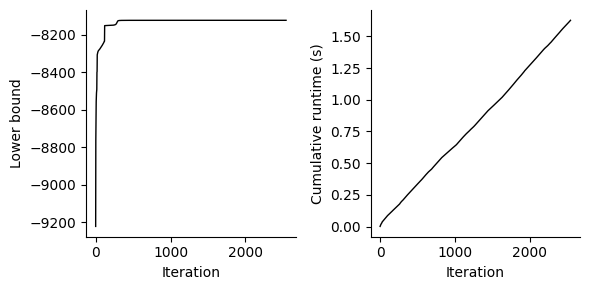

In [6]:
# Display flags indicating fitting procedure status
model.flags.display()

# Plot the lower bound and cumulative runtime at each iteration
model.tracker.plot_fit_progress()

### Visualize recovery of select parameters

#### Loading matrices

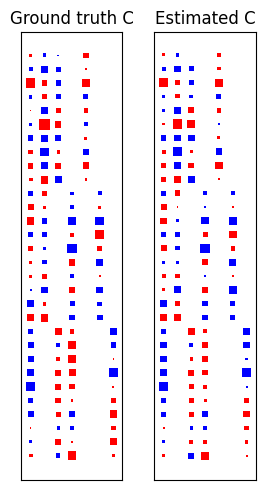

In [7]:
# Ground truth
plt.figure(figsize=(3, 5))
plt.subplot(1, 2, 1)
plt.title("Ground truth C")
gfa_plot.hinton(params_true.C.mean)

# Estimate
# NOTE: In general, the columns of the estimated loading matrices are unordered,
#       and will not match the order in the ground truth. Here, we can reorder
#       and flip the sign of each column to facilitate comparison.
reorder = np.array([4, 3, 2, 1, 0, 5, 6])
rescale = np.array([-1, 1, -1, -1, 1, -1, 1])

plt.subplot(1, 2, 2)
plt.title("Estimated C")
gfa_plot.hinton(model.params.C.mean[:, reorder] * rescale)

plt.tight_layout()
plt.show()

#### ARD parameters

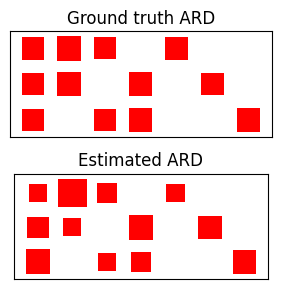

In [8]:
# Ground truth
# Compute the relative shared variance explained by each latent in each group
alpha_inv_true = 1 / params_true.alpha.mean
alpha_inv_rel_true = alpha_inv_true / np.sum(alpha_inv_true, axis=1, keepdims=True)
plt.figure(figsize=(5, 3))
plt.subplot(2, 1, 1)
plt.title("Ground truth ARD")
gfa_plot.hinton(alpha_inv_rel_true)

# Estimate
# NOTE: In general, the columns of the estimated alpha are unordered, and will
#       not match the order in the ground truth. Here, we can reorder the
#       columns to facilitate comparison.

# Compute the relative shared variance explained by each latent in each group
alpha_inv_est = 1 / model.params.alpha.mean
alpha_inv_rel_est = alpha_inv_est / np.sum(alpha_inv_est, axis=1, keepdims=True)
plt.subplot(2, 1, 2)
plt.title("Estimated ARD")
gfa_plot.hinton(alpha_inv_rel_est[:, reorder])

plt.tight_layout()
plt.show()

### Inferring latents and model parameters

Parameters can be easily inferred outside of the fitting procedure, as needed.

In [9]:
model.params.X = model.infer_latents(Y, in_place=False)
model.params.C = model.infer_loadings(Y, in_place=False)
model.params.alpha = model.infer_ard(in_place=False)
model.params.d = model.infer_obs_mean(Y, in_place=False)
model.params.phi = model.infer_obs_prec(Y, in_place=False)

## Explore the model fit with various descriptive statistics

### Performance metrics: Evidence lower bound and leave-group-out prediction

In [10]:
# Evidence lower bound
lb = model.compute_lower_bound(Y)
print(f"Lower bound:        {lb:.4f}")

# Leave-group-out prediction
R2, MSE = gfa_stats.predictive_performance(Y, model.params)
print(f"Leave-group-out R^2: {R2:.4f}")
print(f"                MSE: {MSE:.4f}")

# Leave-one-out prediction
R2, MSE = gfa_stats.predictive_performance(
    Y, model.params, y_dims=np.ones(y_dims.sum(), dtype=int)
)
print(f"Leave-one-out R^2:   {R2:.4f}")
print(f"              MSE:   {MSE:.4f}")

Lower bound:        -8123.4199
Leave-group-out R^2: 0.3254
                MSE: 5.3404
Leave-one-out R^2:   0.4398
              MSE:   4.4351


### Estimated signal-to-noise ratios

In [11]:
# Signal-to-noise ratios of each group, according to estimated model parameters
snr = gfa_stats.compute_snr(model.params.C, model.params.phi, y_dims)

# Format and print the snr values
print("Estimated SNRs:")
for group_idx in range(num_groups):
    print(f"    Group {group_idx+1}: {snr[group_idx]:.4f}")

Estimated SNRs:
    Group 1: 0.8990
    Group 2: 0.8437
    Group 3: 0.7579


### Determine and then visualize the dimensionalities of all types

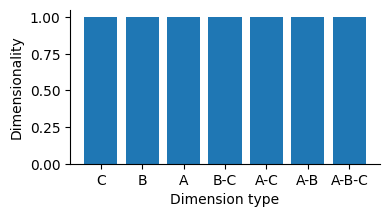

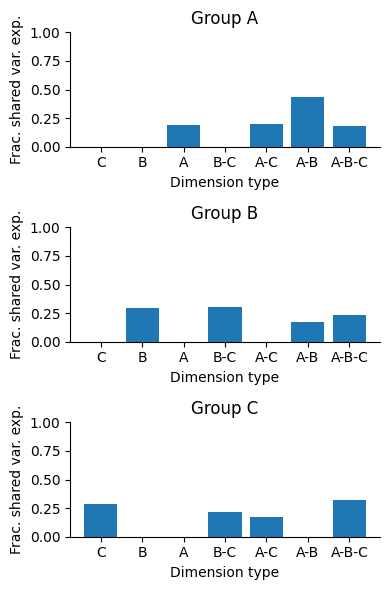

In [12]:
# Compute dimensionalities and shared variance explained by each dimension type
num_dim, sig_dims, var_exp, dim_types = gfa_stats.compute_dimensionalities(
    model.params, cutoff_shared_var=0.02, cutoff_snr=0.001
)

# Visualize the number of each type of dimension
plt.figure(figsize=(4, 2))
gfa_plot.plot_dimensionalities(
    num_dim, dim_types, group_names=["A", "B", "C"], plot_zero_dim=False
)
plt.show()

# Visualize the shared variance explained by each dimension type in each group
plt.figure(figsize=(4, 6))
gfa_plot.plot_var_exp(
    var_exp, dim_types, group_names=["A", "B", "C"], plot_zero_dim=False
)
plt.show()

### Perform a pairwise analysis of interactions between groups

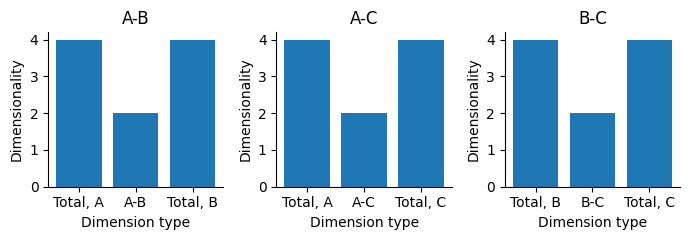

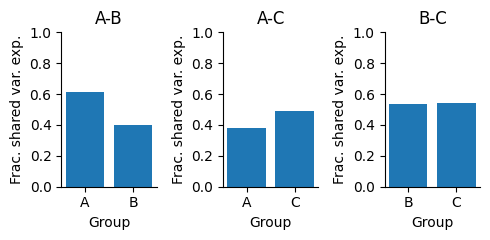

In [13]:
# Compute pairwise dimensionalities and shared variances explained
pair_dims, pair_var_exp, pairs = gfa_stats.compute_dims_pairs(
    num_dim, dim_types, var_exp
)

# Visualize pairwise dimensionalities
plt.figure(figsize=(7, 2.5))
gfa_plot.plot_dims_pairs(pair_dims, pairs, num_groups, group_names=["A", "B", "C"])
plt.show()

# Visualize pairwise shared variances
plt.figure(figsize=(5, 2.5))
gfa_plot.plot_var_exp_pairs(
    pair_var_exp, pairs, num_groups, group_names=["A", "B", "C"], sem_pair_var_exp=None
)